#ANÁLISIS DE PARTIDOS DE LA NBA

#INTEGRANTES:


*   Miguel Angel Angulo
*   Juan David Lizcano
*   Diego Alexander Niño



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

#FASE 1

Se carga el dataset. Se procede a hacer el debido preprocesamiento y limpieza de los datos para así realizar un análisis estadístico breve y dejar nuestro conjunto de datos preparado para cualquier tipo de manipulación a futuro.

# Subir dataset y descripción columnas

In [ ]:
# Importa la herramienta de Colab para subir archivos desde el computador
from google.colab import files
carga = files.upload()

Saving game.xlsx to game.xlsx


In [ ]:
# Se lee el archivo Excel llamado "game.xlsx" y se almacena en el DataFrame "data"
data = pd.read_excel('game.xlsx')
data

,team_home,team_away,game_date,wl_home,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type
0,HUS,NYK,1946-11-01,L,W,25.0,16.0,66.0,-2,24.0,20.0,68.0,Regular Season
1,BOM,PIT,1946-11-02,W,L,20.0,16.0,56.0,5,16.0,19.0,51.0,Regular Season
2,PRO,BOS,1946-11-02,W,L,21.0,17.0,59.0,6,21.0,11.0,53.0,Regular Season
3,CHS,NYK,1946-11-02,W,L,21.0,21.0,63.0,16,16.0,15.0,47.0,Regular Season
4,DEF,WAS,1946-11-02,L,W,10.0,13.0,33.0,-17,18.0,14.0,50.0,Regular Season
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65693,MIA,DEN,2023-06-07,L,W,34.0,15.0,94.0,-15,41.0,22.0,109.0,Playoffs
65694,MIA,DEN,2023-06-09,L,W,35.0,17.0,95.0,-13,39.0,16.0,108.0,Playoffs
65695,DEN,MIA,2023-06-12,W,L,38.0,13.0,94.0,5,33.0,14.0,89.0,Playoffs
65696,LBN,GNS,2023-02-19,L,W,79.0,0.0,175.0,-9,76.0,3.0,184.0,All-Star


**Descripción de las columnas utilizadas en el dataset**

Para el análisis se seleccionaron varias columnas del dataset ***game*** de la NBA. Cada fila del conjunto de datos representa un partido jugado entre dos equipos (uno local y el otro visitante) y las columnas contienen datos y características del juego.

---

**1. team_home**

Tipo de variable: Categórica (texto)

Descripción: Representa el equipo que juega como local en el partido (Nombre del equipo abrebiado).

Importancia: Jugar en casa puede influir en el rendimiento del equipo debido al apoyo del público, familiaridad con la cancha y menor desgaste por viajes.

---

**2. team_away**

Tipo de variable: Categórica (texto)

Descripción: Representa el equipo que juega como visitante en el partido (Nombre del equipo abrebiado).

Importancia: Permite identificar el enfrentamiento entre equipos y analizar diferencias entre rendimiento local y visitante.

---

**3. game_date**

Tipo de variable: Temporal (fecha)

Descripción: Indica la fecha en la que se jugó el partido.

Importancia: Permite realizar análisis cronológicos, estudiar el rendimiento de los equipos a lo largo del tiempo o por temporadas.

---

**4. wl_home**

Tipo de variable: Categórica (binaria)

Descripción: Indica si el equipo local ganó o perdió el partido. Generalmente se representa con valores como W (Win) para victoria o L (Loss) para derrota.

Importancia: Es una variable clave para analizar resultados y puede utilizarse como variable objetivo en modelos de predicción.

---

**5. wl_away**

Tipo de variable: Categórica (binaria)

Descripción: Indica si el equipo visitante ganó o perdió el partido.

Importancia: Complementa la variable del equipo local y permite identificar el resultado final del juego desde la perspectiva del visitante.

---

**6. fgm_home**

Tipo de variable: Numérica (entero)

Descripción: Número de tiros de campo anotados por el equipo local durante el partido.

Importancia: Es una estadística fundamental para medir la eficiencia ofensiva del equipo.

---

**7. ftm_home**

Tipo de variable: Numérica (entero)

Descripción: Número de tiros libres anotados por el equipo local.

Importancia: Los tiros libres contribuyen al puntaje final y reflejan la capacidad del equipo para aprovechar faltas del rival.

---

**8. pts_home**

Tipo de variable: Numérica (entero)

Descripción: Cantidad total de puntos anotados por el equipo local en el partido.

Importancia: Es uno de los indicadores principales del rendimiento ofensivo y determina en gran parte el resultado del juego.

---

**9. plus_minus_home**

Tipo de variable: Numérica (entero)

Descripción: Diferencia de puntos entre el equipo local y el equipo visitante al finalizar el partido.

Importancia: Permite medir la ventaja o desventaja en el marcador del equipo **local**.

---

**10. fgm_away**

Tipo de variable: Numérica (entero)

Descripción: Número de tiros de campo anotados por el equipo visitante.

Importancia: Permite comparar la eficiencia ofensiva entre el equipo visitante y el local.

---

**11. ftm_away**

Tipo de variable: Numérica (entero)

Descripción: Número de tiros libres anotados por el equipo visitante durante el partido.

Importancia: Contribuye al puntaje total del visitante y permite analizar su desempeño ofensivo.

---

**12. pts_away**

Tipo de variable: Numérica (entero)

Descripción: Total de puntos anotados por el equipo visitante en el partido.

Importancia: Permite determinar el resultado del juego y comparar el rendimiento entre ambos equipos.

---

**13. season_type**

Tipo de variable: Categórica

Descripción: Indica el tipo de temporada en la que se jugó el partido.

Importancia: Es relevante porque el nivel de competencia y la intensidad de los partidos puede variar dependiendo de la fase de la temporada.

In [ ]:
# Muestra los nombres de todas las columnas del dataset
data.columns

Index(['team_home', 'team_away', 'game_date', 'wl_home', 'wl_away', 'fgm_home',
       'ftm_home', 'pts_home', 'plus_minus_home', 'fgm_away', 'ftm_away',
       'pts_away', 'season_type'],
      dtype='object')

# Preprocesamiento dataset

Se modifican las columnas **wl_home** y **wl_away**, que originalmente contienen los valores **W** (Win) y **L** (Lose).  
La transformación consiste en convertir estos valores a una representación numérica, donde **W se reemplaza por 1** y **L se reemplaza por 0**.

Este cambio se realiza para que la información pueda ser utilizada de forma más adecuada en análisis de datos, ya que trabajar con valores numéricos facilita el procesamiento y análisis del dataset.

In [ ]:
# Se crea una copia del DataFrame original
d = data.copy()

# Convierte la columna 'wl_home' y 'wl_away'con pd.factorize (0 para 'L', 1 para 'W')
d['wl_home'] = pd.factorize(d['wl_home'])[0]
d['wl_away'] = pd.factorize(d['wl_away'], sort= True)[0]

# Muestra las primeras filas del DataFrame ya transformado
display(d.head())


,team_home,team_away,game_date,wl_home,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type
0,HUS,NYK,1946-11-01,0,1,25.0,16.0,66.0,-2,24.0,20.0,68.0,Regular Season
1,BOM,PIT,1946-11-02,1,0,20.0,16.0,56.0,5,16.0,19.0,51.0,Regular Season
2,PRO,BOS,1946-11-02,1,0,21.0,17.0,59.0,6,21.0,11.0,53.0,Regular Season
3,CHS,NYK,1946-11-02,1,0,21.0,21.0,63.0,16,16.0,15.0,47.0,Regular Season
4,DEF,WAS,1946-11-02,0,1,10.0,13.0,33.0,-17,18.0,14.0,50.0,Regular Season


 Se filtra el dataset para eliminar los partidos correspondientes a **All-Star** y **Pre Season**.  

La intención es trabajar únicamente con los partidos de **Regular Season** y **Playoffs**, ya que estos representan la competencia oficial de la temporada y reflejan de forma más real el rendimiento de los equipos durante el desarrollo del campeonato.

In [ ]:
# Muestra los tipos de temporada presentes antes del filtrado
Tipos_partidos = d["season_type"].unique()
Tipos_partidos

array(['Regular Season', 'Playoffs', 'All-Star', 'Pre Season'],
      dtype=object)

In [ ]:
# Filtra el DataFrame para conservar solo partidos que no sean All-Star ni Pre Season
d = d[d.season_type != "All-Star"][d.season_type != "Pre Season" ]
d

/tmp/ipykernel_660/1874046187.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  d = d[d.season_type != "All-Star"][d.season_type != "Pre Season" ]


,team_home,team_away,game_date,wl_home,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type
0,HUS,NYK,1946-11-01,0,1,25.0,16.0,66.0,-2,24.0,20.0,68.0,Regular Season
1,BOM,PIT,1946-11-02,1,0,20.0,16.0,56.0,5,16.0,19.0,51.0,Regular Season
2,PRO,BOS,1946-11-02,1,0,21.0,17.0,59.0,6,21.0,11.0,53.0,Regular Season
3,CHS,NYK,1946-11-02,1,0,21.0,21.0,63.0,16,16.0,15.0,47.0,Regular Season
4,DEF,WAS,1946-11-02,0,1,10.0,13.0,33.0,-17,18.0,14.0,50.0,Regular Season
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65691,DEN,MIA,2023-06-01,1,0,40.0,16.0,104.0,11,39.0,2.0,93.0,Playoffs
65692,DEN,MIA,2023-06-04,0,1,39.0,19.0,108.0,-3,38.0,18.0,111.0,Playoffs
65693,MIA,DEN,2023-06-07,0,1,34.0,15.0,94.0,-15,41.0,22.0,109.0,Playoffs
65694,MIA,DEN,2023-06-09,0,1,35.0,17.0,95.0,-13,39.0,16.0,108.0,Playoffs


In [ ]:
# Muestra nuevamente los tipos de temporada después del filtrado
Tipos_partidos = d["season_type"].unique()
Tipos_partidos

array(['Regular Season', 'Playoffs'], dtype=object)

Se modifica la columna **season_type**, que originalmente contiene valores categóricos **Regular Season** y **Playoffs**.  

La transformación consiste en convertir estos valores a una representación numérica, donde **Regular Season se representa con 0** y **Playoffs con 1**.  


In [ ]:
# Convierte la columna 'season_type' a formato numérico
# 0: Regular Season
# 1: Playoffs
d['season_type'] = pd.factorize(d['season_type'])[0]
d

,team_home,team_away,game_date,wl_home,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type
0,HUS,NYK,1946-11-01,0,1,25.0,16.0,66.0,-2,24.0,20.0,68.0,0
1,BOM,PIT,1946-11-02,1,0,20.0,16.0,56.0,5,16.0,19.0,51.0,0
2,PRO,BOS,1946-11-02,1,0,21.0,17.0,59.0,6,21.0,11.0,53.0,0
3,CHS,NYK,1946-11-02,1,0,21.0,21.0,63.0,16,16.0,15.0,47.0,0
4,DEF,WAS,1946-11-02,0,1,10.0,13.0,33.0,-17,18.0,14.0,50.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65691,DEN,MIA,2023-06-01,1,0,40.0,16.0,104.0,11,39.0,2.0,93.0,1
65692,DEN,MIA,2023-06-04,0,1,39.0,19.0,108.0,-3,38.0,18.0,111.0,1
65693,MIA,DEN,2023-06-07,0,1,34.0,15.0,94.0,-15,41.0,22.0,109.0,1
65694,MIA,DEN,2023-06-09,0,1,35.0,17.0,95.0,-13,39.0,16.0,108.0,1


#Información data

In [ ]:
# Muestra información general del DataFrame:
# nombres de columnas, cantidad de valores no nulos y tipos de datos
d.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64034 entries, 0 to 65695
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   team_home        64034 non-null  object        
 1   team_away        64034 non-null  object        
 2   game_date        64034 non-null  datetime64[ns]
 3   wl_home          64034 non-null  int64         
 4   wl_away          64034 non-null  int64         
 5   fgm_home         64021 non-null  float64       
 6   ftm_home         64018 non-null  float64       
 7   pts_home         64034 non-null  float64       
 8   plus_minus_home  64034 non-null  int64         
 9   fgm_away         64021 non-null  float64       
 10  ftm_away         64021 non-null  float64       
 11  pts_away         64034 non-null  float64       
 12  season_type      64034 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(4), object(2)
memory usage: 6.8+ MB


In [ ]:
# Muestra el número de filas y columnas del DataFrame
d.shape

(64034, 13)

In [ ]:
# Genera estadísticas descriptivas para las columnas numéricas
d.describe()

,game_date,wl_home,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type
count,64034,64034.000000,64034.000000,64021.000000,64018.000000,64034.000000,64034.000000,64021.000000,64021.000000,64034.000000,64034.000000
mean,1994-09-19 14:09:35.919042816,0.619921,0.380079,39.735837,20.690571,104.670737,3.654387,38.403727,19.779088,101.016351,0.059999
min,1946-11-01 00:00:00,0.000000,0.000000,4.000000,0.000000,18.000000,-58.000000,4.000000,1.000000,19.000000,0.000000
25%,1982-04-11 00:00:00,0.000000,0.000000,35.000000,16.000000,95.000000,-5.000000,34.000000,15.000000,92.000000,0.000000
50%,1997-01-21 00:00:00,1.000000,0.000000,40.000000,20.000000,105.000000,4.000000,38.000000,19.000000,101.000000,0.000000
75%,2010-01-16 00:00:00,1.000000,1.000000,44.000000,25.000000,114.000000,12.000000,43.000000,24.000000,111.000000,0.000000
max,2023-06-12 00:00:00,1.000000,1.000000,72.000000,61.000000,184.000000,73.000000,74.000000,57.000000,186.000000,1.000000
std,NaN,0.485410,0.485410,6.734314,7.132976,14.722594,13.045500,6.442493,6.837118,14.356795,0.237488


 Se realiza un proceso para completar los valores faltantes dentro del dataset.  

La intención es reemplazar los datos que están vacíos en las columnas numéricas utilizando el promedio de cada columna, con el fin de evitar que existan valores nulos dentro del conjunto de datos y poder continuar trabajando con la información de manera completa.

In [ ]:
# Rellena los valores faltantes de las columnas numéricas con la media de cada columna
d = d.fillna(d.mean(numeric_only=True))

# Verifica cuántos valores nulos quedaron en cada columna después del llenado
print("Valores nulos después de rellenar con la media:")
display(d.isnull().sum())

Valores nulos después de rellenar con la media:


,0
team_home,0
team_away,0
game_date,0
wl_home,0
wl_away,0
fgm_home,0
ftm_home,0
pts_home,0
plus_minus_home,0
fgm_away,0


In [ ]:
# Crea una nueva columna con la suma de los puntos del equipo local y visitante
d["total_puntos"] = d["pts_home"] + d["pts_away"]

# Ordena el DataFrame de mayor a menor según el total de puntos anotados en cada partido
d = d.sort_values(by="total_puntos", ascending=False)

# Muestra las últimas 10 filas del DataFrame ordenado
d.tail(10)

,team_home,team_away,game_date,wl_home,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type,total_puntos
179,NYK,BOS,1947-01-25,0,1,17.0,12.0,46.0,-6,21.0,10.0,52.0,0,98.0
209,BOS,NYK,1947-02-06,1,0,18.0,13.0,49.0,1,17.0,14.0,48.0,0,97.0
96,BOM,HUS,1946-12-15,0,1,15.0,16.0,46.0,-4,19.0,12.0,50.0,0,96.0
66,CLR,DEF,1946-12-01,1,0,16.0,17.0,49.0,2,19.0,9.0,47.0,0,96.0
176,BOS,PIT,1947-01-23,1,0,19.0,10.0,48.0,5,18.0,7.0,43.0,0,91.0
67,PIT,BOS,1946-12-02,0,1,17.0,10.0,44.0,-2,17.0,12.0,46.0,0,90.0
63,WAS,PIT,1946-11-30,1,0,16.0,17.0,49.0,9,13.0,14.0,40.0,0,89.0
162,BOS,WAS,1947-01-16,1,0,18.0,11.0,47.0,9,14.0,10.0,38.0,0,85.0
4,DEF,WAS,1946-11-02,0,1,10.0,13.0,33.0,-17,18.0,14.0,50.0,0,83.0
1596,MNL,FTW,1950-11-22,0,1,4.0,10.0,18.0,-1,4.0,11.0,19.0,0,37.0


Se crea una nueva columna llamada **total_tiros_libre**, la cual representa la suma de los tiros libres anotados por el equipo local y el equipo visitante en cada partido.

El dataset se ordena según esta nueva columna de mayor a menor.

In [ ]:
# Muestra las últimas 10 filas del DataFrame ordenado
d["total_tiros_libre"] = d["ftm_home"] + d["ftm_away"]

# Ordena el DataFrame de mayor a menor según el total de tiros libres
d = d.sort_values(by="total_tiros_libre", ascending=False)

# Muestra las primeras 5 filas con los partidos de mayor cantidad de tiros libres
d.head(5)

,team_home,team_away,game_date,wl_home,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type,total_puntos,total_tiros_libre
1041,SYR,AND,1949-11-24,1,0,33.0,59.0,125.0,2,33.0,57.0,123.0,0,248.0,116.0
2632,BOS,SYR,1953-03-21,1,0,27.0,57.0,111.0,6,27.0,51.0,105.0,1,216.0,108.0
3040,MNL,BOS,1954-11-28,1,0,34.0,47.0,115.0,7,26.0,56.0,108.0,0,223.0,103.0
933,NYK,BAL,1949-03-26,1,0,26.0,51.0,103.0,4,26.0,47.0,99.0,1,202.0,98.0
3947,PHW,MNL,1957-11-02,1,0,35.0,48.0,118.0,10,30.0,48.0,108.0,0,226.0,96.0


# Estadísticas

Se realiza un análisis para detectar posibles **valores atípicos (outliers)** en la columna **total_puntos** del dataset.

Para ello se calcula primero el **intervalo intercuartílico (IQR)**.

Posteriormente, se calculan dos límites que ayudan a identificar valores fuera del comportamiento normal de los datos:

- **iqr_home:** representa el intervalo intercuartílico de la variable **total_puntos**, calculado como la diferencia entre el cuartil 75% y el cuartil 25%.
- **Lim_sup:** corresponde al **límite superior**, obtenido sumando 1.5 veces el IQR al cuartil 75%. Los valores que superen este límite pueden considerarse valores atípicos superiores.
- **Lim_inf:** corresponde al **límite inferior**, obtenido restando 1.5 veces el IQR al cuartil 25%. Los valores que estén por debajo de este límite pueden considerarse valores atípicos inferiores.

El objetivo de este procedimiento es identificar posibles valores extremos dentro de la variable **total_puntos**, lo cual permite evaluar si existen partidos con cantidades de puntos inusualmente altas o bajas dentro del dataset.

In [ ]:
# Calcula el rango intercuartílico (IQR) de la variable total_puntos
iqr_home = d["total_puntos"].quantile(0.75) - d["total_puntos"].quantile(0.25)
print("intervalos interquartilico: " + str(iqr_home))

# Calcula el límite superior e inferior para detectar outliers
Lim_sup = d["total_puntos"].quantile(0.75) + 1.5 * iqr_home
Lim_inf = d["total_puntos"].quantile(0.25) - 1.5 * iqr_home
print("Limite superior: " + str(Lim_sup))
print("Limite inferior: " + str(Lim_inf))

intervalos interquartilico: 34.0
Limite superior: 274.0
Limite inferior: 138.0


Se generan gráficos de tipo **boxplot** con el objetivo de visualizar la distribución de la variable **total_puntos** dentro del dataset y observar los valores atípicos.

El primer gráfico muestra la distribución de **total_puntos** separada según el tipo de temporada representado en la variable **season_type**, lo que permite comparar cómo se comporta la cantidad total de puntos en **Regular Season** y **Playoffs**.

El segundo gráfico muestra la distribución general de **total_puntos** considerando todos los partidos del dataset, lo que permite observar de forma global la dispersión de los datos y detectar posibles valores extremos.

<Axes: ylabel='total_puntos'>

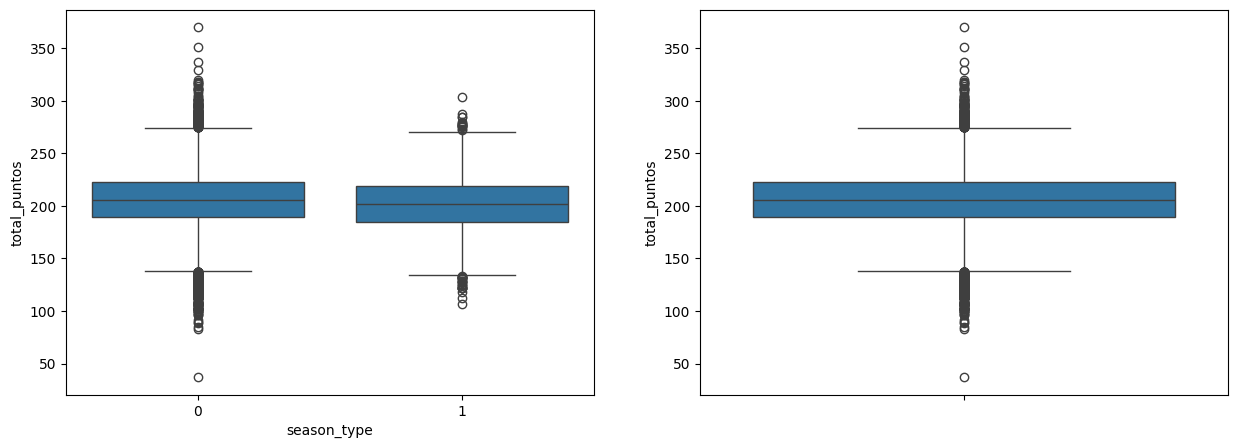

In [ ]:
# Crea una figura con tamaño personalizado
plt.figure(figsize=(15,5))

# Primer gráfico: boxplot de total_puntos por tipo de temporada
plt.subplot(1,2,1)
sns.boxplot(x="season_type", y="total_puntos", data=d)

# Segundo gráfico: boxplot general de total_puntos
plt.subplot(1,2,2)
sns.boxplot(y="total_puntos", data=d)

Se identifican posibles **valores atípicos (outliers)** en la variable **plus_minus_home**, la cual representa la diferencia de puntos entre el equipo local y el equipo visitante en cada partido.


- **iqr_home:** representa el intervalo intercuartílico de la variable **plus_minus_home**, calculado como la diferencia entre el cuartil 75% y el cuartil 25%.
- **Lim_sup:** corresponde al **límite superior**, obtenido sumando 1.5 veces el IQR al cuartil 75%. Los valores que superen este límite pueden considerarse valores atípicos superiores.
- **Lim_inf:** corresponde al **límite inferior**, obtenido restando 1.5 veces el IQR al cuartil 25%. Los valores que estén por debajo de este límite pueden considerarse valores atípicos inferiores.

El objetivo de este procedimiento es analizar si existen partidos donde la diferencia de puntos entre equipos sea inusualmente alta o baja dentro del dataset.

In [ ]:
# Calcula el rango intercuartílico (IQR) de la variable plus_minus_home
iqr_home = d["plus_minus_home"].quantile(0.75) - d["plus_minus_home"].quantile(0.25)
print("intervalos interquartilico: " + str(iqr_home))

# Calcula el límite superior e inferior para detectar outliers
Lim_sup = d["plus_minus_home"].quantile(0.75) + 1.5 * iqr_home
Lim_inf = d["plus_minus_home"].quantile(0.25) - 1.5 * iqr_home
print("Limite superior: " + str(Lim_sup))
print("Limite inferior: " + str(Lim_inf))

intervalos interquartilico: 17.0
Limite superior: 37.5
Limite inferior: -30.5


Se generan **boxplot** para analizar la distribución de la variable **plus_minus_home** dentro del dataset.

El primer gráfico muestra la distribución de **plus_minus_home** según el tipo de temporada representado en la variable **season_type**, lo que permite comparar cómo se comporta la diferencia de puntos entre equipos en **Regular Season** y **Playoffs**.

El segundo gráfico presenta la distribución general de **plus_minus_home** considerando todos los partidos del dataset, lo que permite observar la dispersión de los datos.

<Axes: ylabel='plus_minus_home'>

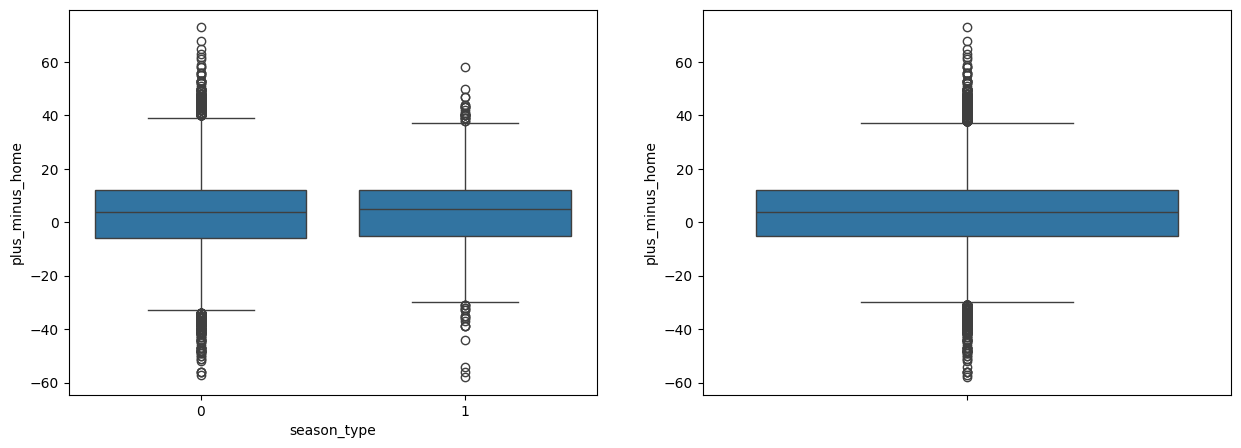

In [ ]:
# Crea una figura con tamaño personalizado
plt.figure(figsize=(15,5))

# Primer gráfico: boxplot de plus_minus_home por tipo de temporada
plt.subplot(1,2,1)
sns.boxplot(x="season_type", y="plus_minus_home", data=d)

# Segundo gráfico: boxplot general de plus_minus_home
plt.subplot(1,2,2)
sns.boxplot(y="plus_minus_home", data=d)

# Visualización

In [ ]:
def configure_plotly_browser_state():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              plotly: 'https://cdn.plot.ly/plotly-latest.min.js?noext',
            },
          });
        </script>
        '''))

configure_plotly_browser_state()

In [ ]:
# Importa y configura cufflinks para gráficos interactivos offline.
import cufflinks as cf
cf.go_offline()

# Asegura la visualización de gráficos Plotly en Colab.
configure_plotly_browser_state()

# Calcula y visualiza la matriz de correlación de variables numéricas.
# kind='heatmap': tipo de gráfico.
d.corr(numeric_only=True).iplot(
    kind='heatmap',
    colorscale="Blues",
    title="Matriz de correlación"
)

In [ ]:
# Importa plotly.graph_objects y cufflinks para gráficos.
import plotly.graph_objects as go
import cufflinks as cf
cf.go_offline()

# Asegura la visualización de gráficos Plotly en Colab.
configure_plotly_browser_state()

# Crea un histograma de 'total_puntos' con Plotly.
# go.Figure: inicializa figura.
# go.Histogram: define el histograma.
# x: datos, nbinsx: número de barras, marker_color: color de barras.
fig = go.Figure(data=[go.Histogram(x=d["total_puntos"], nbinsx=20, marker_color='#1f77b4')])

# Configura el título y etiquetas de los ejes del histograma.
fig.update_layout(
    title_text='Total puntos por game',
    xaxis_title_text='Total Puntos',
    yaxis_title_text='Count'
)

# Muestra el histograma.
fig.show()

# FASE 2

Para esta fase, queremos realizar el analisis del dataset correspondiente a variables presentes en partidos de la NBA. Se busca categorizar los partidos a traves de sus estadisticas como los tiros libres, tiros normales de campo, puntos y tipo de partido para predecir si el equipo de la casa (local) ganó (wl_home = 1) o perdió el partido (wl_home = 0). Además, tambien se analizará como las estadísticas del juego pueden decirnos que tipo de juego se estaba jugando, ya sea un partido de temporada regular o un partido decisivo de playoffs.

Para el análisis de los datos se realiza en secciones anteriores la limpieza de datos donde tratamos los NaN, variables categoricas (convertidas a numéricas) y eliminamos columnas que no eran de nuestro interés.

# Predicción de victoria por parte del local

In [ ]:
#@title **Librerias**
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer
np.random.seed(21)

In [ ]:
d

,team_home,team_away,game_date,wl_home,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type,total_puntos,total_tiros_libre
1041,SYR,AND,1949-11-24,1,0,33.0,59.0,125.0,2,33.0,57.0,123.0,0,248.0,116.0
2632,BOS,SYR,1953-03-21,1,0,27.0,57.0,111.0,6,27.0,51.0,105.0,1,216.0,108.0
3040,MNL,BOS,1954-11-28,1,0,34.0,47.0,115.0,7,26.0,56.0,108.0,0,223.0,103.0
933,NYK,BAL,1949-03-26,1,0,26.0,51.0,103.0,4,26.0,47.0,99.0,1,202.0,98.0
3947,PHW,MNL,1957-11-02,1,0,35.0,48.0,118.0,10,30.0,48.0,108.0,0,226.0,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52907,ATL,MEM,2014-02-08,0,1,30.0,8.0,76.0,-3,37.0,1.0,79.0,0,155.0,9.0
14111,LAL,SDC,1980-03-28,1,0,62.0,2.0,126.0,38,40.0,7.0,88.0,0,214.0,9.0
58111,SAS,ATL,2017-11-20,1,0,40.0,6.0,96.0,11,37.0,3.0,85.0,0,181.0,9.0
51028,CHI,TOR,2012-01-14,1,0,33.0,7.0,77.0,13,30.0,1.0,64.0,0,141.0,8.0


## Técnicas Machine Learning

In [ ]:
#@title **Definición de variables y particionado**
X = d.copy()

# Definimos ground truth como la variable wl_home (gana o pierde la casa)
y = X["wl_home"]

# Dejamos en el datase solo las columnas de interés para la clasificación
X = X[["fgm_home", "ftm_home", "pts_home", "season_type"]]

# Particionamos el dataset en 80 (entrenamiento) - 20 (test)
# Método train_test_split contiene la permutación del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [ ]:
X

,fgm_home,ftm_home,pts_home,season_type
1041,33.0,59.0,125.0,0
2632,27.0,57.0,111.0,1
3040,34.0,47.0,115.0,0
933,26.0,51.0,103.0,1
3947,35.0,48.0,118.0,0
...,...,...,...,...
52907,30.0,8.0,76.0,0
14111,62.0,2.0,126.0,0
58111,40.0,6.0,96.0,0
51028,33.0,7.0,77.0,0


In [ ]:
#@title **Tuning max_depth for Decision Tree**
def tune_DT_max_depth(X, y, max_depth_values=range(2, 21)):
    means, stds = [], []
    for depth in max_depth_values:
        dt_estimator = DecisionTreeClassifier(max_depth=depth, random_state=21)
        # Using 5-fold cross-validation for evaluation
        s = cross_val_score(dt_estimator, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=21), scoring='accuracy')
        means.append(np.mean(s))
        stds.append(np.std(s))

    means = np.array(means)
    stds  = np.array(stds)

    plt.figure(figsize=(10, 6))
    plt.plot(max_depth_values, means, label="Mean Accuracy", color="black")
    plt.fill_between(max_depth_values, means - stds, means + stds, color="blue", alpha=.2, label="Std Dev")
    plt.xlabel("Max Depth")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Accuracy vs. Max Depth")
    plt.xticks(list(max_depth_values)) # Ensure x-axis ticks are integer depths
    plt.legend()
    plt.grid(True)
    plt.show()


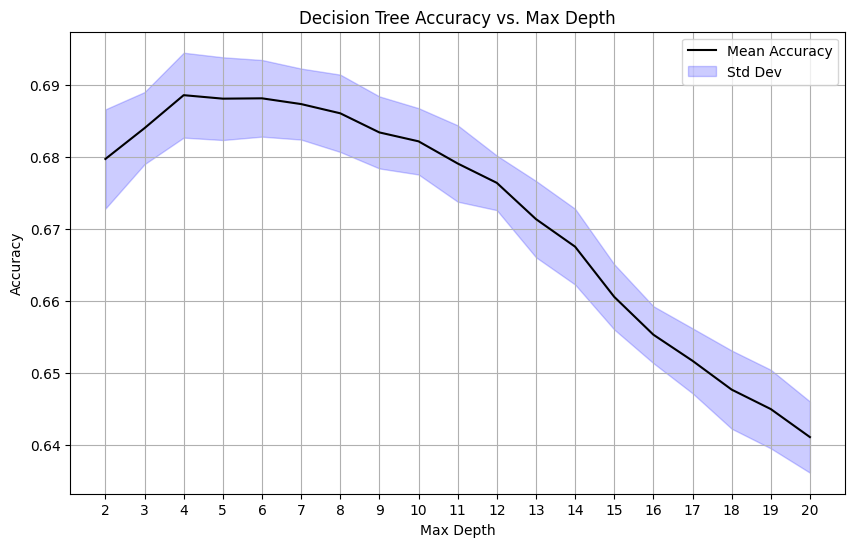

In [ ]:
tune_DT_max_depth(X, y)

In [ ]:
#@title **Decision Tree DT max_depth=**

# Se construye el estimador DecisionTreeClassifier
DT = DecisionTreeClassifier(max_depth=4, random_state=21)

# Entreno los datos DecisionTreeClassifier
DT.fit(X_train,y_train)

# Realizo la predicción DecisionTreeClassifier
y_predDT = DT.predict(X_test)

# Calculo el accuracy DecisionTreeClassifier
accDT = accuracy_score(y_test, y_predDT)

In [ ]:
accDT

0.6929023190442727

In [ ]:
#@title **Tuning max_depth for Random Forest**
def tune_RF_max_depth(X, y, n_estimators_values=range(2, 31)):
    means, stds = [], []
    for estimators in n_estimators_values:
        rf_estimator = RandomForestClassifier(n_estimators=estimators, max_depth=4, random_state=21)
        # Using 5-fold cross-validation for evaluation
        s = cross_val_score(rf_estimator, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=21), scoring='accuracy')
        means.append(np.mean(s))
        stds.append(np.std(s))

    means = np.array(means)
    stds  = np.array(stds)

    plt.figure(figsize=(10, 6))
    plt.plot(n_estimators_values, means, label="Mean Accuracy", color="black")
    plt.fill_between(n_estimators_values, means - stds, means + stds, color="blue", alpha=.2, label="Std Dev")
    plt.xlabel("N estimators")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Accuracy vs. Max Depth")
    plt.xticks(list(n_estimators_values)) # Ensure x-axis ticks are integer depths
    plt.legend()
    plt.grid(True)
    plt.show()

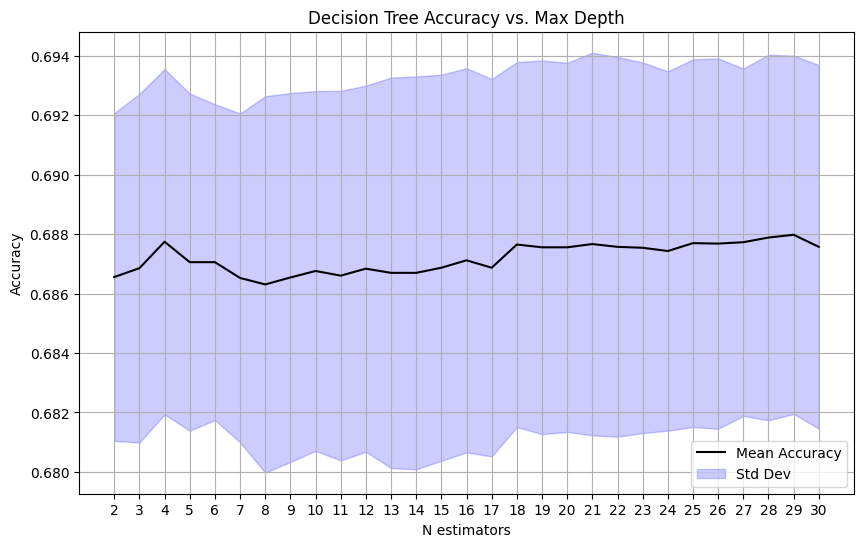

In [ ]:
tune_RF_max_depth(X, y)

In [ ]:
#@title **Random Forest RF**

# Se construye el estimador RF
RF = RandomForestClassifier(n_estimators=4, max_depth=4, random_state=21)

# Entreno los datos RF
RF.fit(X_train,y_train)

# Realizo la predicción RF
y_predRF = RF.predict(X_test)

# Calculo el accuracy RF
accRF = accuracy_score(y_test, y_predRF)

In [ ]:
accRF

0.6940735535254158

In [ ]:
#@title **SVM kernel = "linear"**

# Se construye el estimador SVC
svc = SVC(kernel="linear", random_state=21)

# Entreno los datos SVC
svc.fit(X_train,y_train)

# Realizo la predicción SVC
y_predsvc = svc.predict(X_test)

# Calculo el accuracy SVC
accsvc_lin = accuracy_score(y_test, y_predsvc)

In [ ]:
accsvc_lin

0.6919653314593581

In [ ]:
#@title **SVM kernel = "poly"**

# Se construye el estimador SVC
svc = SVC(kernel="poly", random_state=21)

# Entreno los datos SVC
svc.fit(X_train,y_train)

# Realizo la predicción SVC
y_predsvc = svc.predict(X_test)

# Calculo el accuracy SVC
accsvc_pol = accuracy_score(y_test, y_predsvc)

In [ ]:
accsvc_pol

0.6913406730694152

In [ ]:
#@title **SVM kernel = "rbf"**

# Se construye el estimador SVC
svc = SVC(kernel="rbf", random_state=21)

# Entreno los datos SVC
svc.fit(X_train,y_train)

# Realizo la predicción SVC
y_predsvc = svc.predict(X_test)

# Calculo el accuracy SVC
accsvc_rbf = accuracy_score(y_test, y_predsvc)

In [ ]:
accsvc_rbf

0.689544780198329

## Cross-validation

In [ ]:
# Se utiliza cross_validation para el mismo estimador
s = cross_val_score(RF, X, y, cv=KFold(50, shuffle=True), scoring=make_scorer(accuracy_score))

# Se calcula las medias y desviación estándar de los accuracy_score
acc_mean = np.mean(s)
acc_std = np.std(s)

In [ ]:
acc_mean

np.float64(0.6868218188914911)

## DeepLearning




In [ ]:
#@title **Preparación Dataset y particionado**
X2 = X.copy()
y2 = y.copy()

# Se calcula el número de clases con y
nc = len(y2.unique())

# Remove column names
X2.columns = range(X2.shape[1])
X2 = X2.to_numpy()
y2 = y2.to_numpy()
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=21)

In [ ]:
#@title **Primer modelo**
# Construyo el modelo con sus capas correspondientes
model = tf.keras.Sequential([
  tf.keras.layers.Flatten( input_shape= X_train2[0].shape),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(nc, activation="softmax")])

# Compilo el modelo con los parámetros solicitados
model.compile(optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

# Entreno el modelo
model.fit(X_train2, y_train2, epochs=50)

# Evaluamos loss y accuracy del modelo
test_loss, test_acc = model.evaluate(X_test2, y_test2)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



1601/1601 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6191 - loss: 0.6839
Epoch 2/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6274 - loss: 0.6347
Epoch 3/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6395 - loss: 0.6271
Epoch 4/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6519 - loss: 0.6206
Epoch 5/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6584 - loss: 0.6168
Epoch 6/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6634 - loss: 0.6133
Epoch 7/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6650 - loss: 0.6122
Epoch 8/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6651 - loss: 0.6104
Epoch 9/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6683 - loss: 0.6101
Epoch 10/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6696 - loss: 0.6094
Epoch 11/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6681 - loss: 0.6095
Epoch 12/50
1601/1601 ━━━━━━━━━━━━━━━━━━━

In [ ]:
#@title **Segundo modelo**
# Construyo el modelo con sus capas correspondientes
model2 = tf.keras.Sequential([
  tf.keras.layers.Flatten( input_shape= X_train2[0].shape),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(256, activation="relu"),
  tf.keras.layers.Dense(256, activation="relu"),
  tf.keras.layers.Dense(nc, activation="softmax")])

# Compilo el modelo con los parámetros solicitados
model2.compile(optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

# Entreno el modelo
model2.fit(X_train2, y_train2, epochs=50)

# Evaluamos loss y accuracy del modelo
test_loss2, test_acc2 = model2.evaluate(X_test2, y_test2)

Epoch 1/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 60s 4ms/step - accuracy: 0.6211 - loss: 0.6466
Epoch 2/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6423 - loss: 0.6279
Epoch 3/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6580 - loss: 0.6186
Epoch 4/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6644 - loss: 0.6137
Epoch 5/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6695 - loss: 0.6102
Epoch 6/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6705 - loss: 0.6084
Epoch 7/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6695 - loss: 0.6087
Epoch 8/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6674 - loss: 0.6098
Epoch 9/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6710 - loss: 0.6064
Epoch 10/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6691 - loss: 0.6066
Epoch 11/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6721 - loss: 0.6064
Epoch 12/50
1601/1601 ━━━━━━━

In [ ]:
#@title **Tercer modelo**
# Construyo el modelo con sus capas correspondientes
model3 = tf.keras.Sequential([
  tf.keras.layers.Flatten( input_shape= X_train2[0].shape),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(nc, activation="softmax")])

# Compilo el modelo con los parámetros solicitados
model3.compile(optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

# Entreno el modelo
model3.fit(X_train2, y_train2, epochs=50)

# Evaluamos loss y accuracy del modelo
test_loss3, test_acc3 = model3.evaluate(X_test2, y_test2)

Epoch 1/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6279 - loss: 0.6392
Epoch 2/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6558 - loss: 0.6212
Epoch 3/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6623 - loss: 0.6160
Epoch 4/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6663 - loss: 0.6130
Epoch 5/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6663 - loss: 0.6123
Epoch 6/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6685 - loss: 0.6101
Epoch 7/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6679 - loss: 0.6093
Epoch 8/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6702 - loss: 0.6089
Epoch 9/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6685 - loss: 0.6081
Epoch 10/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6708 - loss: 0.6069
Epoch 11/50
1601/1601 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6713 - loss: 0.6068
Epoch 12/50
1601/1601 ━━━━━━━

## Gráficas de resultados

/tmp/ipykernel_9785/3559937085.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




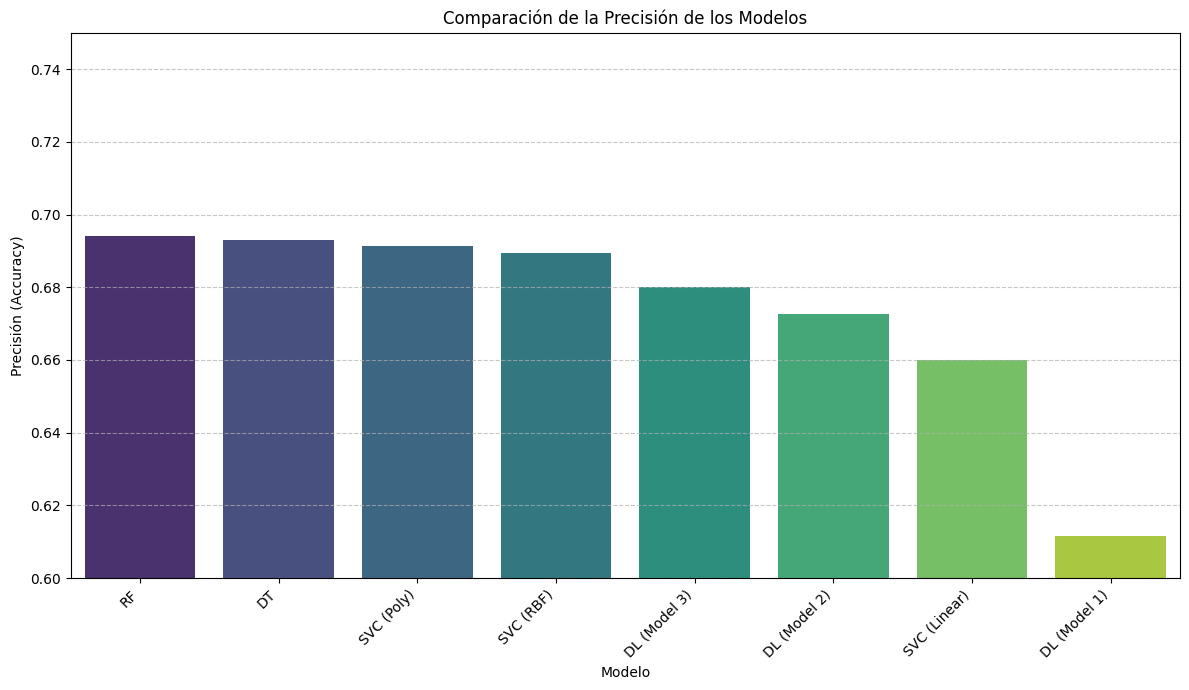

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Recopilar las precisiones de los modelos
accuracies = {
    'DT': accDT,
    'RF': accRF,
    'SVC (Linear)': accsvc_lin,
    'SVC (Poly)': accsvc_pol,
    'SVC (RBF)': accsvc_rbf,
    'DL (Model 1)': test_acc,
    'DL (Model 2)': test_acc2,
    'DL (Model 3)': test_acc3
}

# Crear un DataFrame para facilitar la visualización
accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])

# Ordenar por precisión para una mejor visualización
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Comparación de la Precisión de los Modelos')
plt.xlabel('Modelo')
plt.ylabel('Precisión (Accuracy)')
plt.ylim(0.6, 0.75) # Ajusta los límites del eje Y para una mejor visualización de las diferencias
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Crea un DataFrame para comparar X_test, y_test y y_predRF
results_df = X_test.copy()
results_df['Actual_wl_home'] = y_test
results_df['Predicted_wl_home_RF'] = y_predRF

# Muestra las primeras filas de la tabla de resultados
display(results_df.head(20))

,fgm_home,ftm_home,pts_home,season_type,Actual_wl_home,Predicted_wl_home_RF
51523,24.0,7.0,59.0,0,0,0
40462,33.0,13.0,82.0,0,0,0
16541,40.0,14.0,94.0,0,1,0
28278,33.0,12.0,81.0,0,0,0
43738,31.0,23.0,92.0,0,1,1
47052,43.0,13.0,103.0,0,1,1
27018,38.0,23.0,104.0,0,1,1
57626,38.0,20.0,104.0,0,1,1
30759,33.0,20.0,92.0,0,0,0
56478,38.0,31.0,113.0,0,0,1


# Predicción tipo de partido

## Técnicas Machine Learning

In [ ]:
#@title **Definición de variables y particionado**
X = d.copy()

# Definimos ground truth como la variable wl_home (gana o pierde la casa)
y = X["season_type"]

# Dejamos en el datase solo las columnas de interés para la clasificación
X = X[["fgm_home", "ftm_home", "pts_home", "fgm_away","ftm_away","pts_away"]]

# Particionamos el dataset en 80 (entrenamiento) - 20 (test)
# Método train_test_split contiene la permutación del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=21)

In [ ]:
X

,fgm_home,ftm_home,pts_home,fgm_away,ftm_away,pts_away
1041,33.0,59.0,125.0,33.0,57.0,123.0
2632,27.0,57.0,111.0,27.0,51.0,105.0
3040,34.0,47.0,115.0,26.0,56.0,108.0
933,26.0,51.0,103.0,26.0,47.0,99.0
3947,35.0,48.0,118.0,30.0,48.0,108.0
...,...,...,...,...,...,...
52907,30.0,8.0,76.0,37.0,1.0,79.0
14111,62.0,2.0,126.0,40.0,7.0,88.0
58111,40.0,6.0,96.0,37.0,3.0,85.0
51028,33.0,7.0,77.0,30.0,1.0,64.0


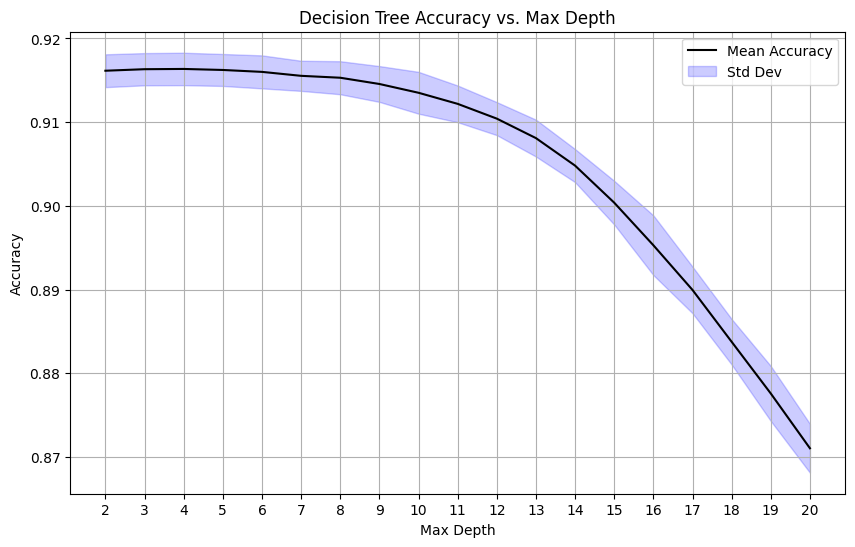

In [ ]:
#@title **Tuning max_depth for Decision Tree**
def tune_DT_max_depth(X, y, max_depth_values=range(2, 21)):
    means, stds = [], []
    for depth in max_depth_values:
        dt_estimator = DecisionTreeClassifier(max_depth=depth, random_state=21)
        # Using 5-fold cross-validation for evaluation
        s = cross_val_score(dt_estimator, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=21), scoring='accuracy')
        means.append(np.mean(s))
        stds.append(np.std(s))

    means = np.array(means)
    stds  = np.array(stds)

    plt.figure(figsize=(10, 6))
    plt.plot(max_depth_values, means, label="Mean Accuracy", color="black")
    plt.fill_between(max_depth_values, means - stds, means + stds, color="blue", alpha=.2, label="Std Dev")
    plt.xlabel("Max Depth")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Accuracy vs. Max Depth")
    plt.xticks(list(max_depth_values)) # Ensure x-axis ticks are integer depths
    plt.legend()
    plt.grid(True)
    plt.show()

tune_DT_max_depth(X, y)

In [ ]:
#@title **Decision Tree DT max_depth=**

# Se construye el estimador DecisionTreeClassifier
DT = DecisionTreeClassifier(max_depth=4, random_state=21)

# Entreno los datos DecisionTreeClassifier
DT.fit(X_train,y_train)

# Realizo la predicción DecisionTreeClassifier
y_predDT = DT.predict(X_test)

# Calculo el accuracy DecisionTreeClassifier
accDT = accuracy_score(y_test, y_predDT)

accDT

0.915220700152207

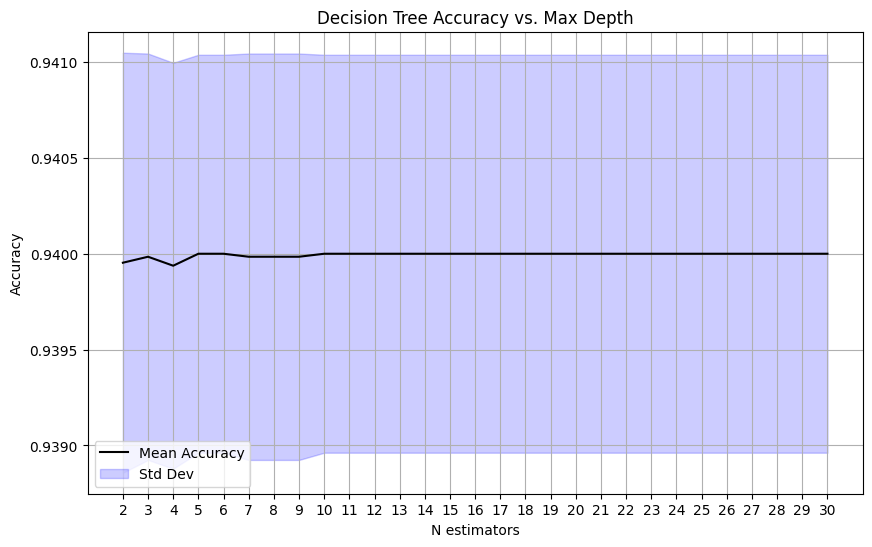

In [ ]:
#@title **Tuning max_depth for Random Forest**
def tune_RF_max_depth(X, y, n_estimators_values=range(2, 31)):
    means, stds = [], []
    for estimators in n_estimators_values:
        rf_estimator = RandomForestClassifier(n_estimators=estimators, max_depth=4, random_state=21)
        # Using 5-fold cross-validation for evaluation
        s = cross_val_score(rf_estimator, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=21), scoring='accuracy')
        means.append(np.mean(s))
        stds.append(np.std(s))

    means = np.array(means)
    stds  = np.array(stds)

    plt.figure(figsize=(10, 6))
    plt.plot(n_estimators_values, means, label="Mean Accuracy", color="black")
    plt.fill_between(n_estimators_values, means - stds, means + stds, color="blue", alpha=.2, label="Std Dev")
    plt.xlabel("N estimators")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Accuracy vs. Max Depth")
    plt.xticks(list(n_estimators_values)) # Ensure x-axis ticks are integer depths
    plt.legend()
    plt.grid(True)
    plt.show()

tune_RF_max_depth(X, y)

In [ ]:
#@title **Random Forest RF**

# Se construye el estimador RF
RF = RandomForestClassifier(n_estimators=11, max_depth=4, random_state=21)

# Entreno los datos RF
RF.fit(X_train,y_train)

# Realizo la predicción RF
y_predRF = RF.predict(X_test)

# Calculo el accuracy RF
accRF = accuracy_score(y_test, y_predRF)

accRF

0.915144596651446

In [ ]:
#@title **Cross-validation**

# Se utiliza cross_validation para el mismo estimador
s = cross_val_score(RF, X, y, cv=KFold(50, shuffle=True), scoring=make_scorer(accuracy_score))

# Se calcula las medias y desviación estándar de los accuracy_score
acc_mean = np.mean(s)
acc_std = np.std(s)

acc_mean

np.float64(0.9163900510177467)

## DeepLearning

In [ ]:
#@title **Preparación Dataset y particionado**
X2 = X.copy()
y2 = y.copy()

# Se calcula el número de clases con y
nc = len(y2.unique())

# Remove column names
X2.columns = range(X2.shape[1])
X2 = X2.to_numpy()
y2 = y2.to_numpy()
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=21)

In [ ]:
#@title **Primer modelo**
# Construyo el modelo con sus capas correspondientes
model = tf.keras.Sequential([
  tf.keras.layers.Flatten( input_shape= X_train2[0].shape),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(nc, activation="softmax")])

# Compilo el modelo con los parámetros solicitados
model.compile(optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

# Entreno el modelo
model.fit(X_train2, y_train2, epochs=50)

# Evaluamos loss y accuracy del modelo
test_loss, test_acc = model.evaluate(X_test2, y_test2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9149 - loss: 0.3969
Epoch 2/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9165 - loss: 0.3469
Epoch 3/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9165 - loss: 0.3441
Epoch 4/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9165 - loss: 0.3417
Epoch 5/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9165 - loss: 0.3397
Epoch 6/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9165 - loss: 0.3382
Epoch 7/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9165 - loss: 0.3363
Epoch 8/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9165 - loss: 0.3360
Epoch 9/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9165 - loss: 0.3356
Epoch 10/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9166 - loss: 0.3339
Epoch 11/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9165 - loss: 0.3332
Epoch 12/50
1643/1643 ━━━━━━━━

In [ ]:
#@title **Segundo modelo**
# Construyo el modelo con sus capas correspondientes
model2 = tf.keras.Sequential([
  tf.keras.layers.Flatten( input_shape= X_train2[0].shape),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(64, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(256, activation="relu"),
  tf.keras.layers.Dense(256, activation="relu"),
  tf.keras.layers.Dense(nc, activation="softmax")])

# Compilo el modelo con los parámetros solicitados
model2.compile(optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

# Entreno el modelo
model2.fit(X_train2, y_train2, epochs=50)

# Evaluamos loss y accuracy del modelo
test_loss2, test_acc2 = model2.evaluate(X_test2, y_test2)

Epoch 1/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9160 - loss: 0.3557
Epoch 2/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9165 - loss: 0.3458
Epoch 3/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9165 - loss: 0.3433
Epoch 4/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9165 - loss: 0.3412
Epoch 5/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9165 - loss: 0.3391
Epoch 6/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9165 - loss: 0.3372
Epoch 7/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9165 - loss: 0.3353
Epoch 8/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9165 - loss: 0.3351
Epoch 9/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9165 - loss: 0.3340
Epoch 10/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9166 - loss: 0.3332
Epoch 11/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9166 - loss: 0.3325
Epoch 12/50
1643/1643 ━━━━━━━

In [ ]:
#@title **Tercer modelo**
# Construyo el modelo con sus capas correspondientes
model3 = tf.keras.Sequential([
  tf.keras.layers.Flatten( input_shape= X_train2[0].shape),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(128, activation="relu"),
  tf.keras.layers.Dense(nc, activation="softmax")])

# Compilo el modelo con los parámetros solicitados
model3.compile(optimizer=tf.keras.optimizers.SGD(),
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

# Entreno el modelo
model3.fit(X_train2, y_train2, epochs=50)

# Evaluamos loss y accuracy del modelo
test_loss3, test_acc3 = model3.evaluate(X_test2, y_test2)

Epoch 1/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9162 - loss: 0.3531
Epoch 2/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9165 - loss: 0.3488
Epoch 3/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9165 - loss: 0.3462
Epoch 4/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9165 - loss: 0.3440
Epoch 5/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9165 - loss: 0.3422
Epoch 6/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9165 - loss: 0.3403
Epoch 7/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9165 - loss: 0.3386
Epoch 8/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9165 - loss: 0.3377
Epoch 9/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9165 - loss: 0.3363
Epoch 10/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9165 - loss: 0.3350
Epoch 11/50
1643/1643 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9165 - loss: 0.3337
Epoch 12/50
1643/1643 ━━━━━━━

## Gráfica comparativa

/tmp/ipykernel_14331/2434726039.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')


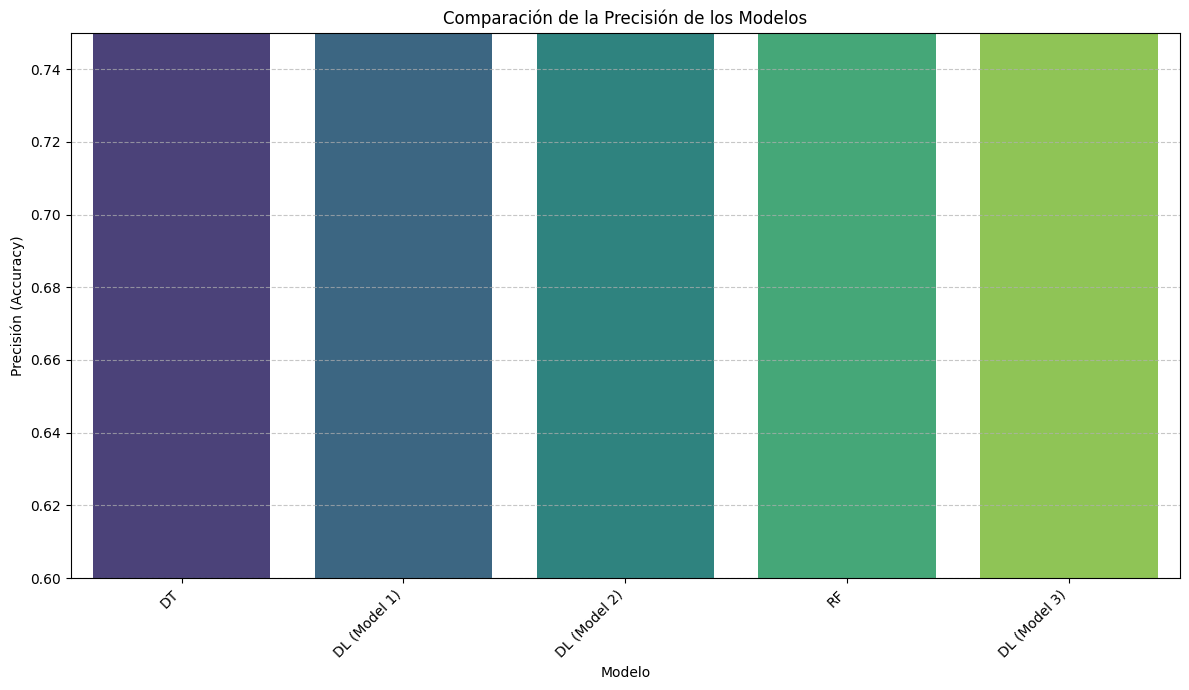

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Recopilar las precisiones de los modelos
accuracies = {
    'DT': accDT,
    'RF': accRF,
    'DL (Model 1)': test_acc,
    'DL (Model 2)': test_acc2,
    'DL (Model 3)': test_acc3
}

# Crear un DataFrame para facilitar la visualización
accuracy_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])

# Ordenar por precisión para una mejor visualización
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Comparación de la Precisión de los Modelos')
plt.xlabel('Modelo')
plt.ylabel('Precisión (Accuracy)')
plt.ylim(0.6, 0.75) # Ajusta los límites del eje Y para una mejor visualización de las diferencias
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# FASE 3

## PCA

In [ ]:
X = d.copy()
y = X["wl_home"]
X = X.drop(columns=["wl_home", "team_home",	"team_away",
                    "game_date", "total_puntos",	"total_tiros_libre"])

X

,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type
1041,0,33.0,59.0,125.0,2,33.0,57.0,123.0,0
2632,0,27.0,57.0,111.0,6,27.0,51.0,105.0,1
3040,0,34.0,47.0,115.0,7,26.0,56.0,108.0,0
933,0,26.0,51.0,103.0,4,26.0,47.0,99.0,1
3947,0,35.0,48.0,118.0,10,30.0,48.0,108.0,0
...,...,...,...,...,...,...,...,...,...
52907,1,30.0,8.0,76.0,-3,37.0,1.0,79.0,0
14111,0,62.0,2.0,126.0,38,40.0,7.0,88.0,0
58111,0,40.0,6.0,96.0,11,37.0,3.0,85.0,0
51028,0,33.0,7.0,77.0,13,30.0,1.0,64.0,0


In [ ]:
from sklearn.decomposition import PCA

print('X shape: ', X.shape)

# Whiten=True entrega los datos estandarizados
pca = PCA(n_components= 2, whiten=True)
X_pca = pca.fit_transform(X)
print('X: ', X.shape, ' X_pca: ', X_pca.shape)

X shape:  (64034, 9)
X:  (64034, 9)  X_pca:  (64034, 2)


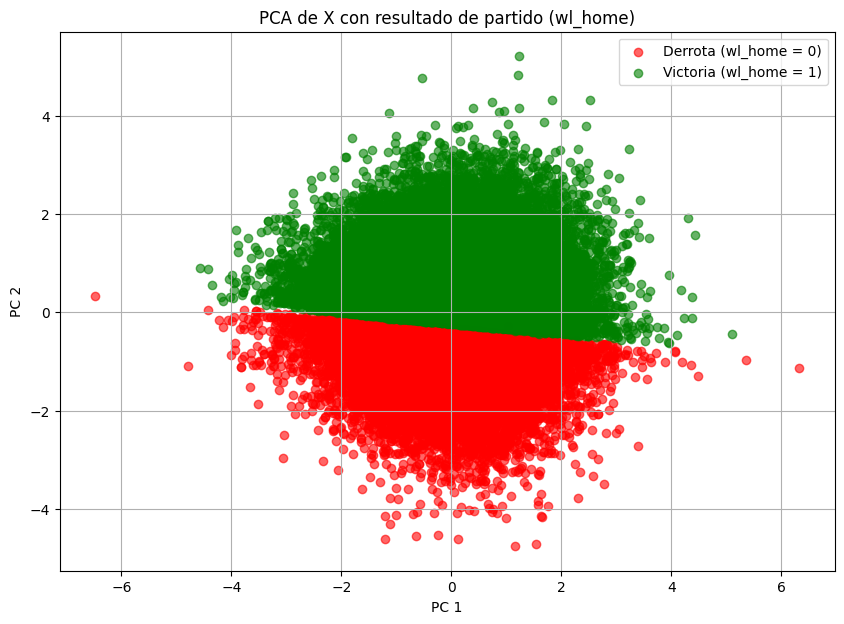

In [ ]:
import matplotlib.pyplot as plt

# Gráfico con las componentes transformadas
plt.figure(figsize=(10, 7))

# Plot 'Derrota' (y=0) en rojo
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='red', alpha=0.6, label='Derrota (wl_home = 0)')

# Plot 'Victoria' (y=1) en verde
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='green', alpha=0.6, label='Victoria (wl_home = 1)')

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA de X con resultado de partido (wl_home)")
plt.legend()
plt.grid(True)
plt.show()

### Contribución de las características originales a las Componentes Principales

Podemos examinar los **vectores propios (eigenvectors)** de cada componente principal. Estos vectores nos indican cómo se combinan las características originales para formar cada componente. Un valor absoluto más alto en un vector propio para una característica específica significa una mayor contribución de esa característica a la componente principal.

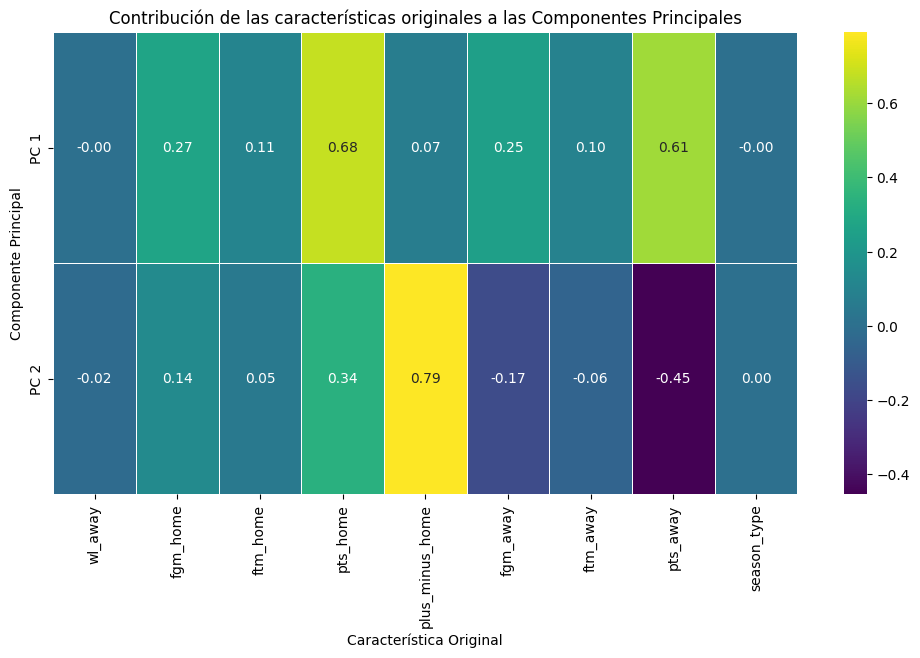


Contribución de las características a las Componentes Principales:


,wl_away,fgm_home,ftm_home,pts_home,plus_minus_home,fgm_away,ftm_away,pts_away,season_type
PC 1,-0.001762,0.273951,0.108762,0.680910,0.068940,0.245882,0.098805,0.611970,-0.000427
PC 2,-0.023339,0.136838,0.048473,0.336366,0.790878,-0.171966,-0.059985,-0.454512,0.000276


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener los componentes principales (eigenvectors)
components = pca.components_

# Crear un DataFrame para visualizar las contribuciones
# Las filas son las componentes principales, las columnas son las características originales
components_df = pd.DataFrame(components, columns=X.columns, index=['PC 1', 'PC 2'])

# Visualizar las contribuciones de cada característica a las dos primeras PCs
plt.figure(figsize=(12, 6))
sns.heatmap(components_df, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Contribución de las características originales a las Componentes Principales')
plt.ylabel('Componente Principal')
plt.xlabel('Característica Original')
plt.show()

print("\nContribución de las características a las Componentes Principales:")
display(components_df)

### Segundo caso sin puntos home, visitante ni diferencia

In [ ]:
X2 = X.drop(columns=["pts_home", "pts_away", "plus_minus_home"])

X2

,wl_home,wl_away,fgm_home,ftm_home,fgm_away,ftm_away,season_type
1041,1,0,33.0,59.0,33.0,57.0,0
2632,1,0,27.0,57.0,27.0,51.0,1
3040,1,0,34.0,47.0,26.0,56.0,0
933,1,0,26.0,51.0,26.0,47.0,1
3947,1,0,35.0,48.0,30.0,48.0,0
...,...,...,...,...,...,...,...
52907,0,1,30.0,8.0,37.0,1.0,0
14111,1,0,62.0,2.0,40.0,7.0,0
58111,1,0,40.0,6.0,37.0,3.0,0
51028,1,0,33.0,7.0,30.0,1.0,0


In [ ]:
from sklearn.decomposition import PCA

print('X shape: ', X2.shape)

pca = PCA(n_components= 2, whiten=True)
X2_pca = pca.fit_transform(X2)
print('X: ', X2.shape, ' X_pca: ', X2_pca.shape)

X shape:  (64034, 7)
X:  (64034, 7)  X_pca:  (64034, 2)


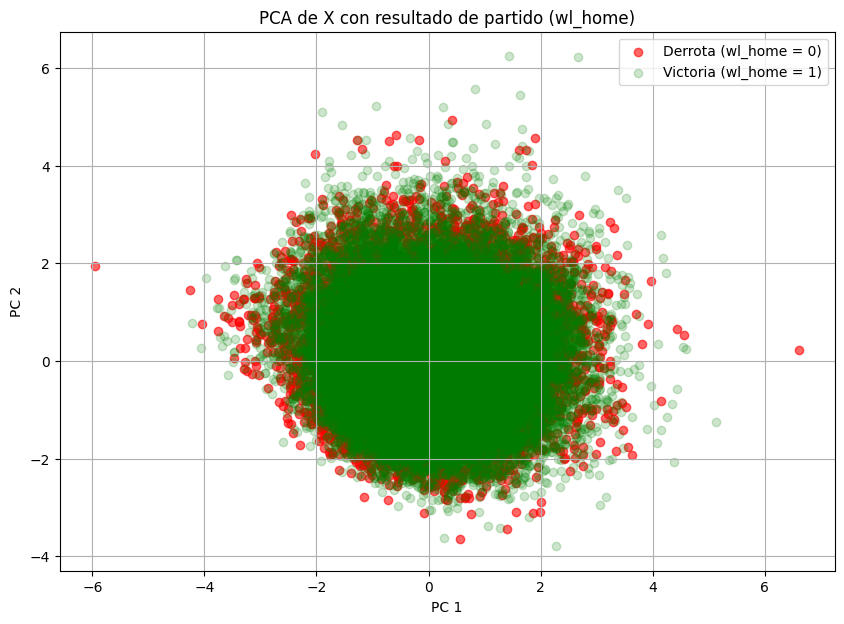

In [ ]:
import matplotlib.pyplot as plt

# Gráfico con las componentes transformadas
plt.figure(figsize=(10, 7))

# Plot 'Derrota' (y=0) en rojo
plt.scatter(X2_pca[y == 0, 0], X2_pca[y == 0, 1], color='red', alpha=0.6, label='Derrota (wl_home = 0)')

# Plot 'Victoria' (y=1) en verde
plt.scatter(X2_pca[y == 1, 0], X2_pca[y == 1, 1], color='green', alpha=0.2, label='Victoria (wl_home = 1)')

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA de X con resultado de partido (wl_home)")
plt.legend()
plt.grid(True)
plt.show()

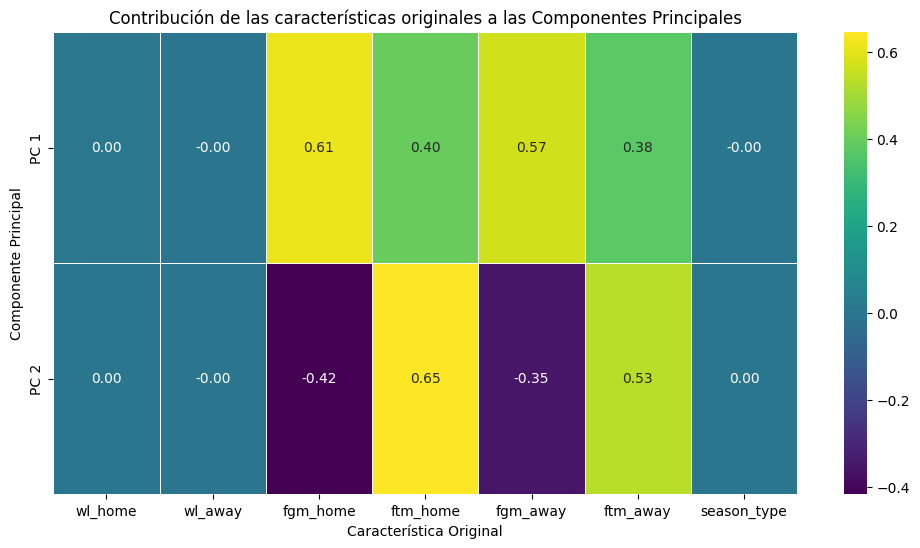


Contribución de las características a las Componentes Principales:


,wl_home,wl_away,fgm_home,ftm_home,fgm_away,ftm_away,season_type
PC 1,0.002897,-0.002897,0.613214,0.397913,0.569665,0.375628,-0.000955
PC 2,0.001372,-0.001372,-0.416097,0.645900,-0.354615,0.532840,0.001722


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener los componentes principales (eigenvectors)
components = pca.components_

# Crear un DataFrame para visualizar las contribuciones
# Las filas son las componentes principales, las columnas son las características originales
components_df = pd.DataFrame(components, columns=X2.columns, index=['PC 1', 'PC 2'])

# Visualizar las contribuciones de cada característica a las dos primeras PCs
plt.figure(figsize=(12, 6))
sns.heatmap(components_df, cmap='viridis', annot=True, fmt=".2f", linewidths=.5)
plt.title('Contribución de las características originales a las Componentes Principales')
plt.ylabel('Componente Principal')
plt.xlabel('Característica Original')
plt.show()

print("\nContribución de las características a las Componentes Principales:")
display(components_df)

## K-MEANS

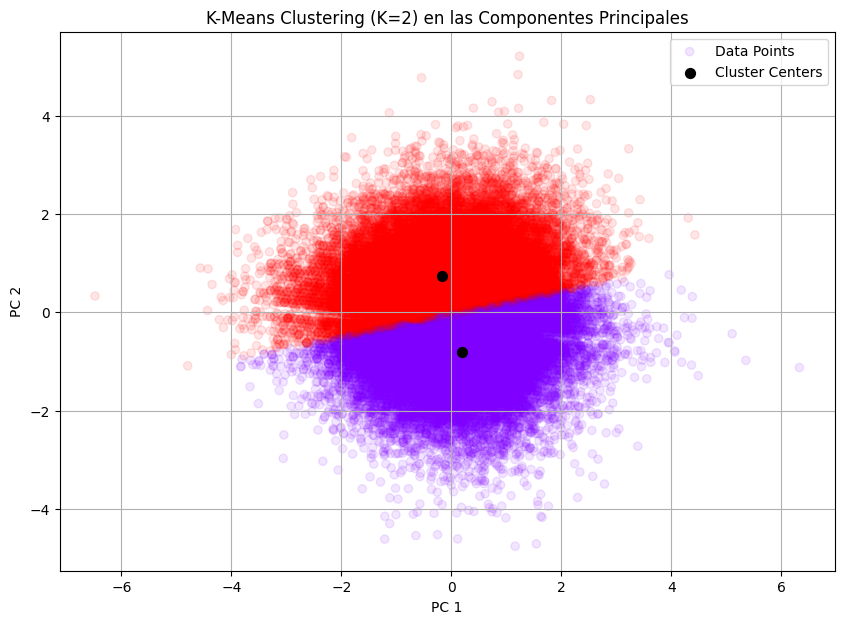

Shape of cluster centers: (2, 2)
Shape of cluster labels: (64034,)


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Num clases: Ganó local, perdió local
K_value = 2

kmeans = KMeans(n_clusters=K_value, random_state=21, n_init=10)
kmeans.fit(X_pca)

# Obtenemos las etiquetas de los clusters
clusters = kmeans.labels_

# Transformar los centros de los clústeres al espacio PCA para graficar.
cluster_centers_pca = kmeans.cluster_centers_

plt.figure(figsize=(10, 7))
#Graficar los puntos de datos transformados por PCA, coloreados por las etiquetas de los clústeres de K-Means.
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
            cmap='rainbow', alpha=0.1, label='Data Points')

# Graficar los centros de los clusters transformados
plt.scatter(cluster_centers_pca[:, 0],
            cluster_centers_pca[:, 1], color='black',
            marker='.', s=200, label='Cluster Centers')

plt.title(f'K-Means Clustering (K={K_value}) en las Componentes Principales')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True)
plt.show()

print("Shape of cluster centers:", kmeans.cluster_centers_.shape)
print("Shape of cluster labels:", kmeans.labels_.shape)

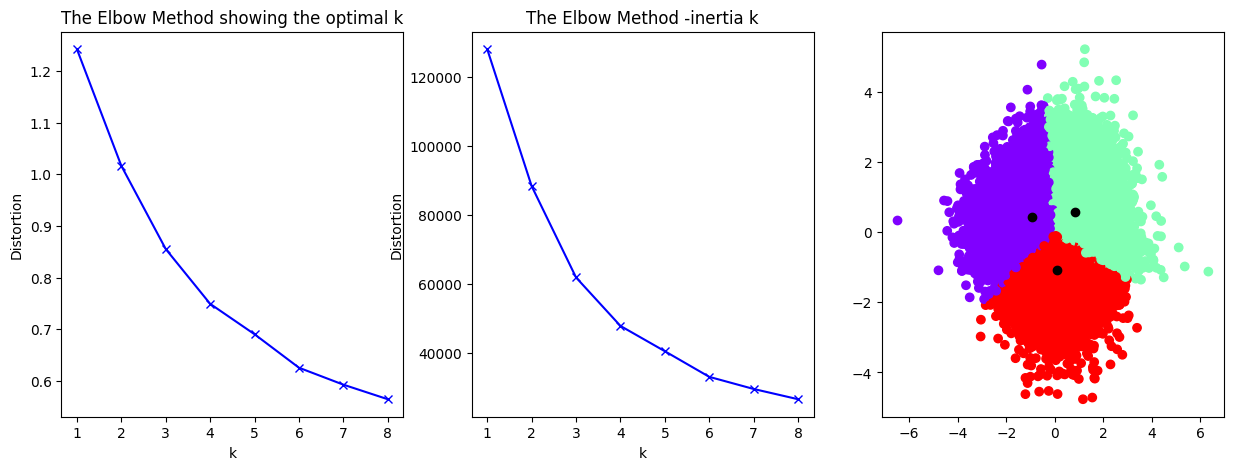

In [ ]:
# @ markdown **Elbow approach**
from scipy.spatial.distance import cdist

distortions = []
wss = [] #Within-Cluster-Sum of Squared
K = range(1,9)
for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init='auto')
    kmeanModel.fit(X_pca)
    distortions.append(sum(np.min(cdist(X_pca, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / X.shape[0])
    wss.append(kmeanModel.inertia_)
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.plot(K, distortions, 'bx-'); plt.xlabel('k');plt.ylabel('Distorsion')
plt.title('El metodo Elbow mostrando el k optimo')
plt.subplot(132)
plt.plot(K, wss, 'bx-'); plt.xlabel('k');plt.ylabel('Distorsion')
plt.title('El metodo Elbow -inertia k')
plt.subplot(133)
kmeanModel = KMeans(n_clusters=3, n_init='auto')
kmeanModel.fit(X_pca)
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeanModel.labels_, cmap='rainbow');
plt.scatter(kmeanModel.cluster_centers_[:,0] ,kmeanModel.cluster_centers_[:,1], color='black')

## DBSCAN

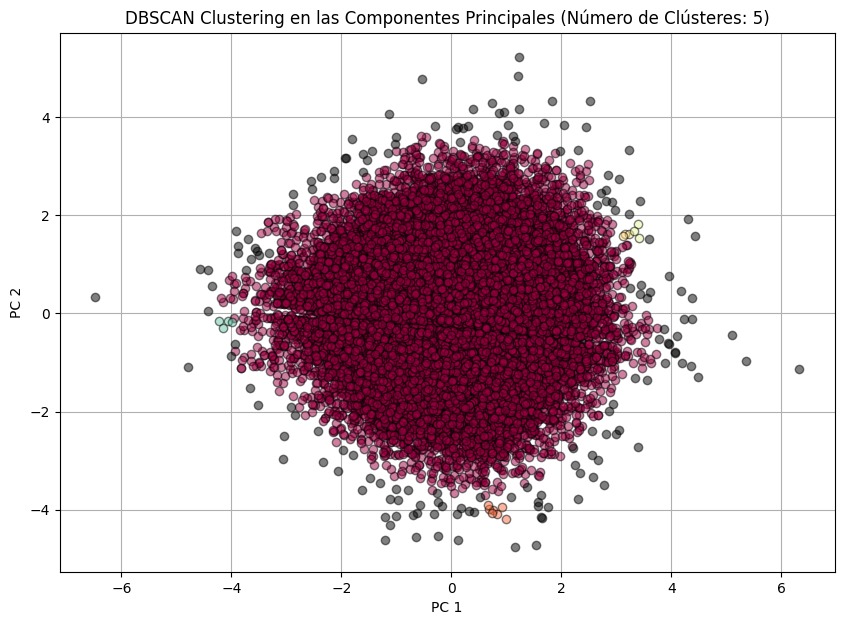

Número estimado de clústeres: 5
Número de puntos de ruido: 163


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

DBS = DBSCAN(eps=.2)
DBS.fit(X_pca)

# Obtener las etiquetas de los clústeres de DBSCAN
# Los puntos etiquetados como -1 son considerados ruido
clusters_dbscan = DBS.labels_

# Número de clústeres encontrados (excluyendo el ruido)
n_clusters_ = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)

plt.figure(figsize=(10, 7))

# Plotear los puntos de datos, coloreados por las etiquetas de los clústeres de DBSCAN
# Los puntos de ruido (-1) se representarán en negro
unique_labels = set(clusters_dbscan)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Negro para el ruido
        col = [0, 0, 0, 1]

    class_member_mask = (clusters_dbscan == k)

    xy = X_pca[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6, alpha=0.5)

plt.title(f'DBSCAN Clustering en las Componentes Principales (Número de Clústeres: {n_clusters_})')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.grid(True)
plt.show()

print(f"Número estimado de clústeres: {n_clusters_}")
print(f"Número de puntos de ruido: {list(clusters_dbscan).count(-1)}")

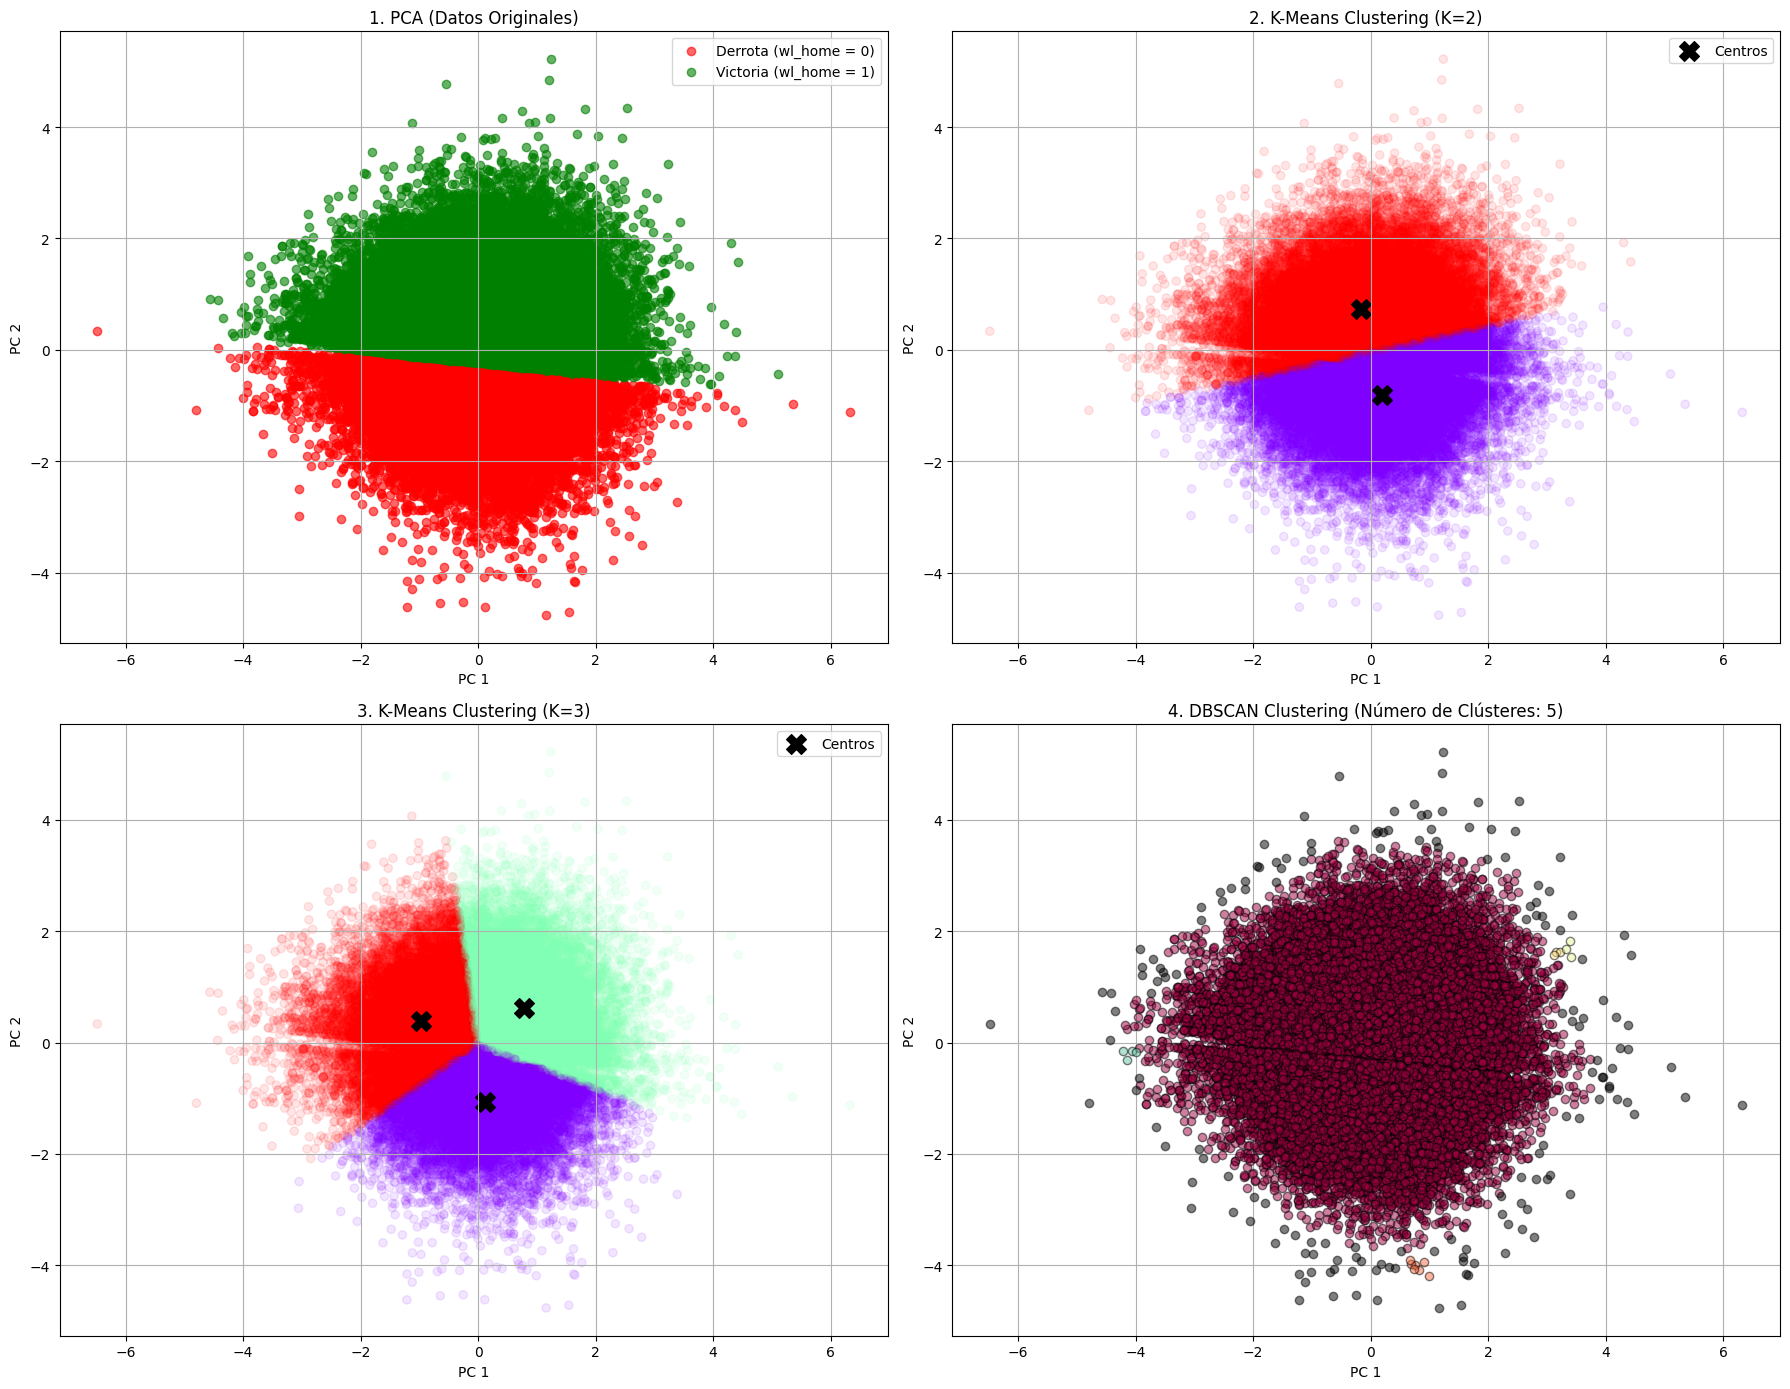

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, DBSCAN

# Assuming X_pca and y are already defined from previous steps

# 1. K-Means with K=2 (already computed, re-running for clarity)
kmeans_2 = KMeans(n_clusters=2, random_state=21, n_init=10)
kmeans_2.fit(X_pca)
clusters_kmeans_2 = kmeans_2.labels_
cluster_centers_kmeans_2 = kmeans_2.cluster_centers_

# 2. K-Means with K=3
kmeans_3 = KMeans(n_clusters=3, random_state=21, n_init=10)
kmeans_3.fit(X_pca)
clusters_kmeans_3 = kmeans_3.labels_
cluster_centers_kmeans_3 = kmeans_3.cluster_centers_

# 3. DBSCAN (already computed, re-using clusters_dbscan)
# DBS = DBSCAN(eps=.2) # Assuming eps=0.2 from previous cell
# DBS.fit(X_pca)
# clusters_dbscan = DBS.labels_

# Create the 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Subplot 1: X_pca (original data, colored by wl_home)
axes[0].scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='red', alpha=0.6, label='Derrota (wl_home = 0)')
axes[0].scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='green', alpha=0.6, label='Victoria (wl_home = 1)')
axes[0].set_title('1. PCA (Datos Originales)')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: K-Means (K=2)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans_2, cmap='rainbow', alpha=0.1)
axes[1].scatter(cluster_centers_kmeans_2[:, 0], cluster_centers_kmeans_2[:, 1], color='black', marker='X', s=200, label='Centros')
axes[1].set_title('2. K-Means Clustering (K=2)')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend()
axes[1].grid(True)

# Subplot 3: K-Means (K=3)
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans_3, cmap='rainbow', alpha=0.1)
axes[2].scatter(cluster_centers_kmeans_3[:, 0], cluster_centers_kmeans_3[:, 1], color='black', marker='X', s=200, label='Centros')
axes[2].set_title('3. K-Means Clustering (K=3)')
axes[2].set_xlabel('PC 1')
axes[2].set_ylabel('PC 2')
axes[2].legend()
axes[2].grid(True)

# Subplot 4: DBSCAN
unique_labels_dbscan = set(clusters_dbscan)
colors_dbscan = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels_dbscan))]

for k, col in zip(unique_labels_dbscan, colors_dbscan):
    if k == -1:
        # Negro para el ruido
        col = [0, 0, 0, 1]
    class_member_mask_dbscan = (clusters_dbscan == k)
    xy_dbscan = X_pca[class_member_mask_dbscan]
    axes[3].plot(xy_dbscan[:, 0], xy_dbscan[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6, alpha=0.5)
axes[3].set_title(f'4. DBSCAN Clustering (Número de Clústeres: {len(unique_labels_dbscan) - (1 if -1 in unique_labels_dbscan else 0)})')
axes[3].set_xlabel('PC 1')
axes[3].set_ylabel('PC 2')
axes[3].grid(True)

plt.tight_layout()
plt.show()

A continuación, se presenta un análisis de las visualizaciones de agrupamiento, comparando los resultados de K-Means y DBSCAN con los datos originales transformados por PCA.

### Interpretación de los Subplots:

1.  **PCA (Datos Originales)**:
    *   Este gráfico muestra la distribución de los partidos en el espacio de dos componentes principales (PC1 y PC2), coloreados según el resultado del partido (`wl_home`: rojo para derrota, verde para victoria).
    *   **PC1** está fuertemente influenciada por la **puntuación total** (pts_home, pts_away) y los **tiros de campo** (fgm_home, fgm_away). Valores altos en PC1 corresponden a partidos de alta puntuación, mientras que valores bajos indican partidos de baja puntuación.
    *   **PC2** está dominada por la **diferencia de puntos del equipo local** (`plus_minus_home`). Valores altos en PC2 sugieren que el equipo local ganó por un margen amplio, y valores bajos (negativos) indican que perdió por un margen amplio.
    *   Observamos una **superposición considerable** entre los puntos rojos (derrotas locales) y verdes (victorias locales). Esto sugiere que, aunque PCA reduce la dimensionalidad, la victoria o derrota del equipo local no es linealmente separable o fácil de distinguir solo con estas dos componentes principales.

2.  **K-Means Clustering (K=2)**:
    *   En este subplot, K-Means ha dividido los datos en **dos clústeres esféricos**. Dado que `K=2` podría interpretarse como un intento de separar los partidos en los que el equipo local gana de aquellos en los que pierde, los clústeres representarían dos grupos principales basados en las características promedio del juego.
    *   Generalmente, un clúster podría agrupar partidos donde las victorias o derrotas del local son más pronunciadas en alguna dirección del espacio PCA (e.g., partidos de mayor puntuación y victorias locales vs. partidos de menor puntuación y derrotas locales). Sin embargo, la naturaleza de K-Means (basada en centroides y distancia euclidiana) puede generar agrupaciones que no necesariamente se alinean perfectamente con los resultados de `wl_home` debido a la superposición observada en el gráfico original.
    *   Los marcadores 'X' negros representan los centroides de estos dos clústeres.

3.  **K-Means Clustering (K=3)**:
    *   Con `K=3`, un número sugerido por el método del codo (Elbow Method), K-Means busca tres agrupaciones distintas.
    *   Los tres clústeres identificados aquí probablemente corresponden a las interpretaciones discutidas previamente:
        *   Un clúster de **victorias dominantes de local en partidos de alta puntuación** (PC1 alta, PC2 alta).
        *   Un clúster de **derrotas claras de local en partidos de baja puntuación** (PC1 baja, PC2 baja/negativa).
        *   Un clúster más central de **partidos equilibrados o de puntuación media**.
    *   Esta división ofrece una visión más matizada de los tipos de partidos en comparación con `K=2`, diferenciando no solo el resultado general sino también la intensidad del juego.

4.  **DBSCAN Clustering**:
    *   DBSCAN es un algoritmo basado en densidad que identifica clústeres como regiones densas de puntos, marcando los puntos aislados como ruido (en negro).
    *   Este gráfico muestra **5 clústeres distintos** y **163 puntos de ruido** (`eps=0.2`). La capacidad de DBSCAN para identificar clústeres de formas arbitrarias (no necesariamente esféricas como K-Means) y su detección de ruido son evidentes aquí.
    *   Los 5 clústeres indican que hay **5 patrones de densidad significativamente diferentes** en las características del juego (en el espacio PCA). Los puntos de ruido representan partidos con características muy atípicas, que no se agrupan densamente con otros partidos.
    *   DBSCAN puede ser útil para descubrir estructuras de datos inesperadas y para filtrar anomalías (ruido), lo que proporciona una perspectiva diferente sobre la agrupación de los partidos de la NBA.